In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


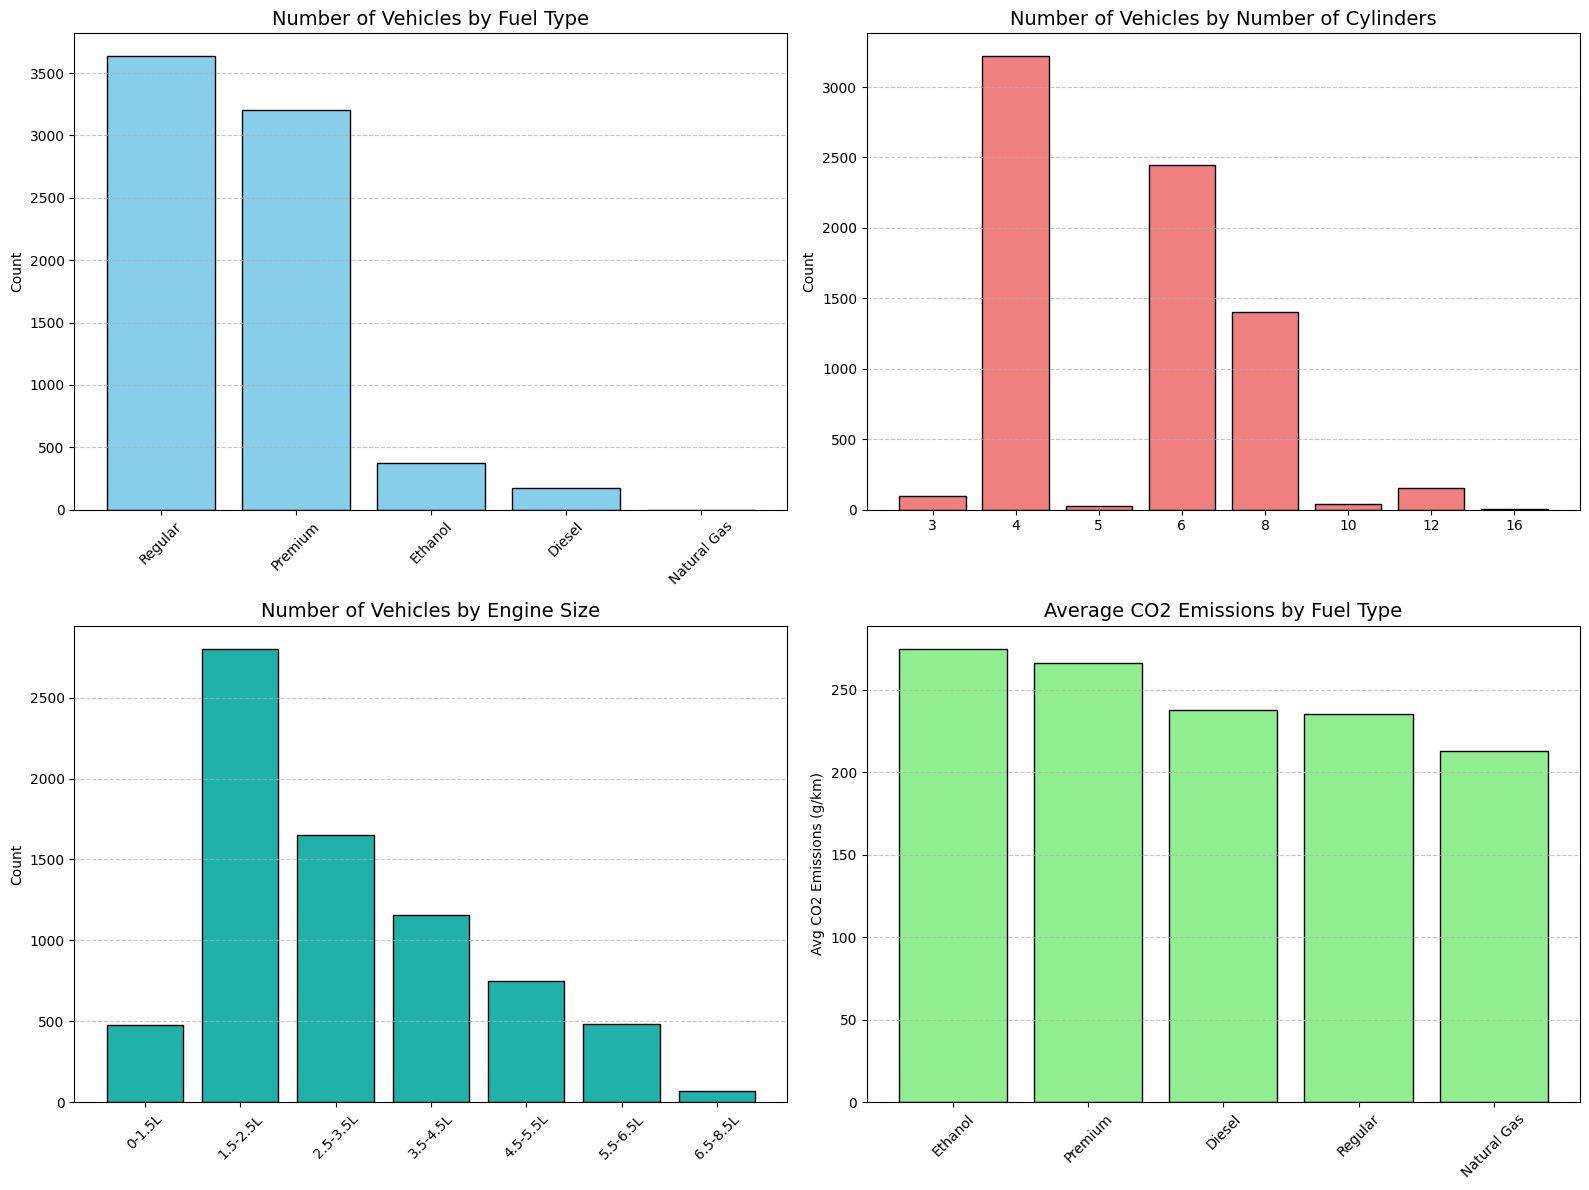

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('CO2 Emissions_Canada.csv')

# --- Data Preparation ---
# 1. Fuel Type Mapping
fuel_map = {'Z': 'Premium', 'X': 'Regular', 'D': 'Diesel', 'E': 'Ethanol', 'N': 'Natural Gas'}
df['Fuel Name'] = df['Fuel Type'].map(fuel_map)
fuel_counts = df['Fuel Name'].value_counts()
fuel_avg = df.groupby('Fuel Name')['CO2 Emissions(g/km)'].mean().sort_values(ascending=False)

# 2. Cylinder Counts
cylinder_counts = df['Cylinders'].value_counts().sort_index()

# 3. Engine Size Bins
engine_bins = [0, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 8.5]
engine_labels = ['0-1.5L', '1.5-2.5L', '2.5-3.5L', '3.5-4.5L', '4.5-5.5L', '5.5-6.5L', '6.5-8.5L']
df['Engine Size Bin'] = pd.cut(df['Engine Size(L)'], bins=engine_bins, labels=engine_labels)
engine_counts = df['Engine Size Bin'].value_counts().sort_index()

# --- Plotting in a Single Plane (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Vehicles by Fuel Type (Top Left)
axes[0, 0].bar(fuel_counts.index, fuel_counts.values, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Number of Vehicles by Fuel Type', fontsize=14)
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Vehicles by Cylinders (Top Right)
axes[0, 1].bar(cylinder_counts.index.astype(str), cylinder_counts.values, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Number of Vehicles by Number of Cylinders', fontsize=14)
axes[0, 1].set_ylabel('Count')

# Plot 3: Vehicles by Engine Size (Bottom Left)
axes[1, 0].bar(engine_counts.index.astype(str), engine_counts.values, color='lightseagreen', edgecolor='black')
axes[1, 0].set_title('Number of Vehicles by Engine Size', fontsize=14)
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)


# Plot 4: Avg CO2 by Fuel Type (Bottom Right)
axes[1, 1].bar(fuel_avg.index, fuel_avg.values, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Average CO2 Emissions by Fuel Type', fontsize=14)
axes[1, 1].set_ylabel('Avg CO2 Emissions (g/km)')
axes[1, 1].tick_params(axis='x', rotation=45)

# Add grids and adjust layout
for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [87]:
df = pd.read_csv('CO2 Emissions_Canada.csv')
df = df[['Engine Size(L)', 'Cylinders', 'Fuel Type', 'CO2 Emissions(g/km)']]


In [88]:
print("Here after Contributed by: Anand Murthy")
df

Here after Contributed by: Anand Murthy


,Engine Size(L),Cylinders,Fuel Type,CO2 Emissions(g/km)
0,2.0,4,Z,196
1,2.4,4,Z,221
2,1.5,4,Z,136
3,3.5,6,Z,255
4,3.5,6,Z,244
...,...,...,...,...
7380,2.0,4,Z,219
7381,2.0,4,Z,232
7382,2.0,4,Z,240
7383,2.0,4,Z,232


In [89]:
print("Missing values in each column:\n", df.isnull().sum())

Missing values in each column:
 Engine Size(L)         0
Cylinders              0
Fuel Type              0
CO2 Emissions(g/km)    0
dtype: int64


In [90]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 5069


In [91]:

duplicates_all = df[df.duplicated(keep=False)]
print(duplicates_all.sort_values(by='Engine Size(L)').head(10))

      Engine Size(L)  Cylinders Fuel Type  CO2 Emissions(g/km)
3189             0.9          3         Z                  157
3190             0.9          3         Z                  157
943              1.0          3         Z                  147
944              1.0          3         Z                  147
3687             1.0          3         X                  176
2073             1.0          3         Z                  150
2072             1.0          3         Z                  150
3688             1.0          3         X                  164
4767             1.0          3         X                  176
4768             1.0          3         X                  164


In [92]:
df_clean= df.drop_duplicates()
print("Number of rows after removing duplicates:", len(df_clean))

Number of rows after removing duplicates: 2316


In [93]:
df_clean

,Engine Size(L),Cylinders,Fuel Type,CO2 Emissions(g/km)
0,2.0,4,Z,196
1,2.4,4,Z,221
2,1.5,4,Z,136
3,3.5,6,Z,255
4,3.5,6,Z,244
...,...,...,...,...
7339,2.5,4,X,158
7340,2.5,4,X,156
7348,5.7,8,X,385
7357,5.7,8,X,381


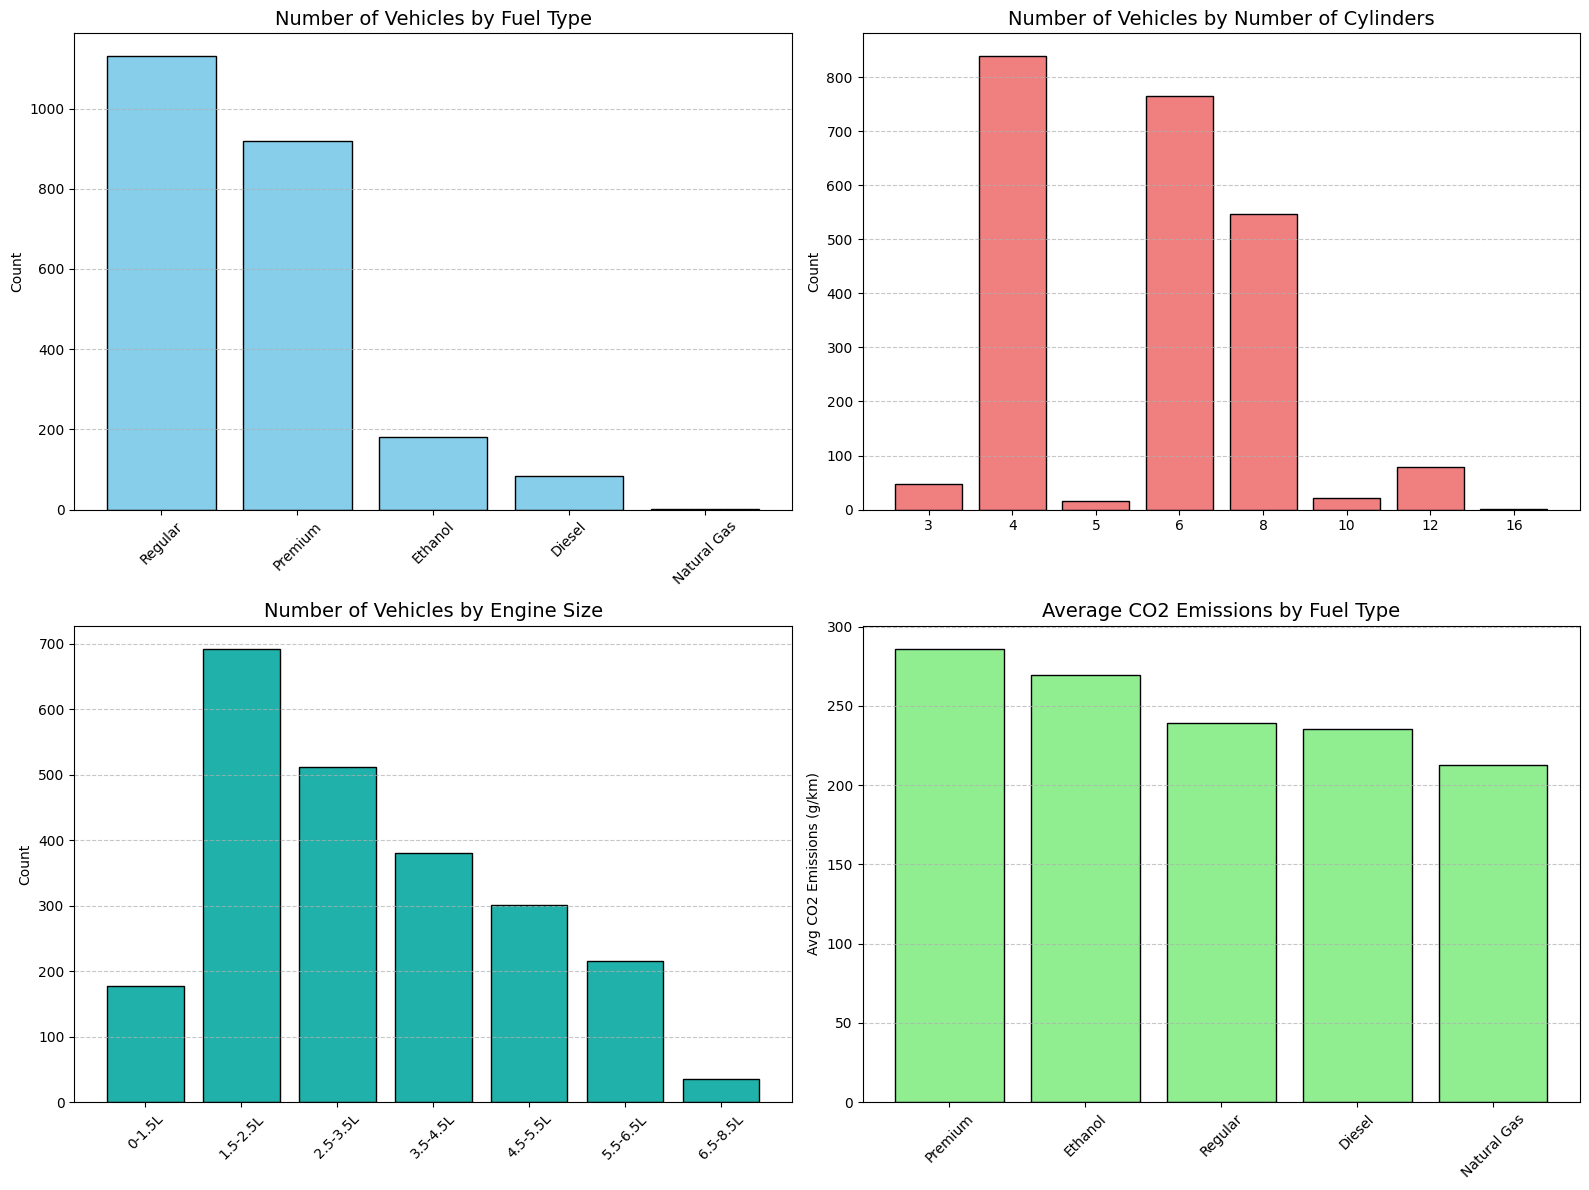

In [94]:

# Load the dataset
df = pd.read_csv('CO2 Emissions.csv')

# --- Data Preparation ---
# 1. Fuel Type Mapping
fuel_map = {'Z': 'Premium', 'X': 'Regular', 'D': 'Diesel', 'E': 'Ethanol', 'N': 'Natural Gas'}
df['Fuel Name'] = df['Fuel Type'].map(fuel_map)
fuel_counts = df['Fuel Name'].value_counts()
fuel_avg = df.groupby('Fuel Name')['CO2 Emissions(g/km)'].mean().sort_values(ascending=False)

# 2. Cylinder Counts
cylinder_counts = df['Cylinders'].value_counts().sort_index()

# 3. Engine Size Bins
engine_bins = [0, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 8.5]
engine_labels = ['0-1.5L', '1.5-2.5L', '2.5-3.5L', '3.5-4.5L', '4.5-5.5L', '5.5-6.5L', '6.5-8.5L']
df['Engine Size Bin'] = pd.cut(df['Engine Size(L)'], bins=engine_bins, labels=engine_labels)
engine_counts = df['Engine Size Bin'].value_counts().sort_index()

# --- Plotting in a Single Plane (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Vehicles by Fuel Type (Top Left)
axes[0, 0].bar(fuel_counts.index, fuel_counts.values, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Number of Vehicles by Fuel Type', fontsize=14)
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Vehicles by Cylinders (Top Right)
axes[0, 1].bar(cylinder_counts.index.astype(str), cylinder_counts.values, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Number of Vehicles by Number of Cylinders', fontsize=14)
axes[0, 1].set_ylabel('Count')

# Plot 3: Vehicles by Engine Size (Bottom Left)
axes[1, 0].bar(engine_counts.index.astype(str), engine_counts.values, color='lightseagreen', edgecolor='black')
axes[1, 0].set_title('Number of Vehicles by Engine Size', fontsize=14)
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Avg CO2 by Fuel Type (Bottom Right)
axes[1, 1].bar(fuel_avg.index, fuel_avg.values, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Average CO2 Emissions by Fuel Type', fontsize=14)
axes[1, 1].set_ylabel('Avg CO2 Emissions (g/km)')
axes[1, 1].tick_params(axis='x', rotation=45)

# Add grids and adjust layout
for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [95]:
df = pd.read_csv('CO2 Emissions.csv')

Contrubited by: Suha Maria
Engine Size Analysis:
- Lower Bound: -1.4499999999999997
- Upper Bound: 7.75
- Number of outliers removed: 5
- Final row count: 2311

--- Sample of Outliers Being Removed ---
      Engine Size(L)  Cylinders Fuel Type  CO2 Emissions(g/km)
538              8.4         10         Z                  389
700              8.4         10         Z                  363
1055             8.4         10         Z                  364
1540             8.4         10         Z                  387
1818             8.0         16         Z                  522


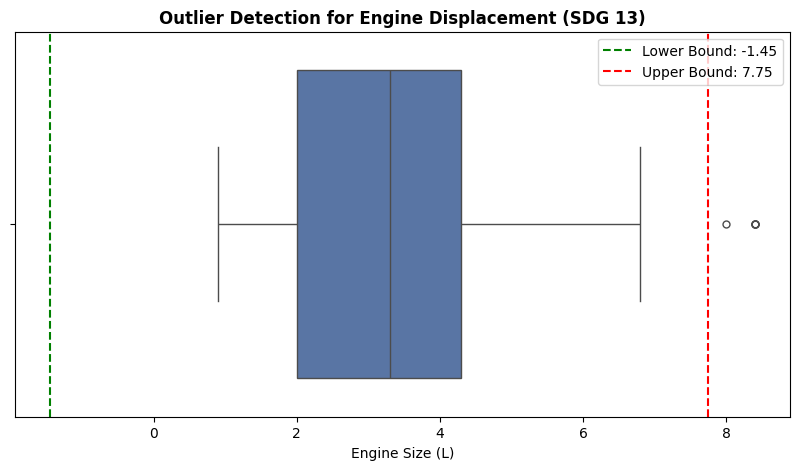

In [96]:
print("Contrubited by: Suha Maria")
Q1 = df['Engine Size(L)'].quantile(0.25)
Q3 = df['Engine Size(L)'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Identify and Remove Outliers
outliers = df[(df['Engine Size(L)'] < lower_bound) | (df['Engine Size(L)'] > upper_bound)]
df_cleaned = df[(df['Engine Size(L)'] >= lower_bound) & (df['Engine Size(L)'] <= upper_bound)]

print(f"Engine Size Analysis:")
print(f"- Lower Bound: {lower_bound}")
print(f"- Upper Bound: {upper_bound}")
print(f"- Number of outliers removed: {len(outliers)}")
print(f"- Final row count: {len(df_cleaned)}")

print("\n--- Sample of Outliers Being Removed ---")
print(outliers.head())
# 4. Visualize with a Boxplot (optional but recommended for your report)
# Updated Visualization for your Model_Development Branch
plt.figure(figsize=(10, 5))

# Create the boxplot with specific styling
sns.boxplot(x=df['Engine Size(L)'], color='#4C72B0', fliersize=5)

# Add visual markers for the bounds you calculated
plt.axvline(lower_bound, color='green', linestyle='--', label=f'Lower Bound: {lower_bound:.2f}')
plt.axvline(upper_bound, color='red', linestyle='--', label=f'Upper Bound: {upper_bound:.2f}')

plt.title('Outlier Detection for Engine Displacement (SDG 13)', fontweight='bold')
plt.xlabel('Engine Size (L)')
plt.legend()
plt.show()


In [97]:
df_cleaned.shape

(2311, 4)

In [98]:
df_cleaned

,Engine Size(L),Cylinders,Fuel Type,CO2 Emissions(g/km)
0,2.0,4,Z,196
1,2.4,4,Z,221
2,1.5,4,Z,136
3,3.5,6,Z,255
4,3.5,6,Z,244
...,...,...,...,...
2311,2.5,4,X,158
2312,2.5,4,X,156
2313,5.7,8,X,385
2314,5.7,8,X,381


In [99]:
df_cleaned.to_csv('CO2_Cleaned_No_Outliers.csv', index=False)

In [100]:
X = df.iloc[:, :-1].values  # Engine Size, Cylinders, Fuel Type
y = df.iloc[:, -1].values  # CO2 Emissions

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [2])], 
    remainder='passthrough'
)

In [102]:
ct

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""

In [103]:
X = np.array(ct.fit_transform(X))

In [104]:
X

array([[0.0, 0.0, 0.0, ..., 1.0, 2.0, 4],
       [0.0, 0.0, 0.0, ..., 1.0, 2.4, 4],
       [0.0, 0.0, 0.0, ..., 1.0, 1.5, 4],
       ...,
       [0.0, 0.0, 0.0, ..., 0.0, 5.7, 8],
       [0.0, 0.0, 0.0, ..., 0.0, 5.7, 8],
       [0.0, 0.0, 0.0, ..., 0.0, 2.0, 4]], shape=(2316, 7), dtype=object)

In [105]:
# 1. Get the feature names from the encoder
# This identifies columns like 'Fuel_X', 'Fuel_Z', etc.
encoded_cols = ct.named_transformers_['encoder'].get_feature_names_out(['Fuel Type'])
all_cols = list(encoded_cols) + ['Engine Size(L)', 'Cylinders']

# 2. Convert the NumPy array back to a DataFrame
df_final_csv = pd.DataFrame(X, columns=all_cols)

# 3. Add the target variable (CO2 Emissions) back to the DataFrame 
df_final_csv['CO2 Emissions(g/km)'] = y

# 4. Save to CSV
df_final_csv.to_csv('CO2_Model_Ready_Encoded.csv', index=False)

print("Final model-ready CSV saved as 'CO2_Model_Ready_Encoded.csv'")

Final model-ready CSV saved as 'CO2_Model_Ready_Encoded.csv'


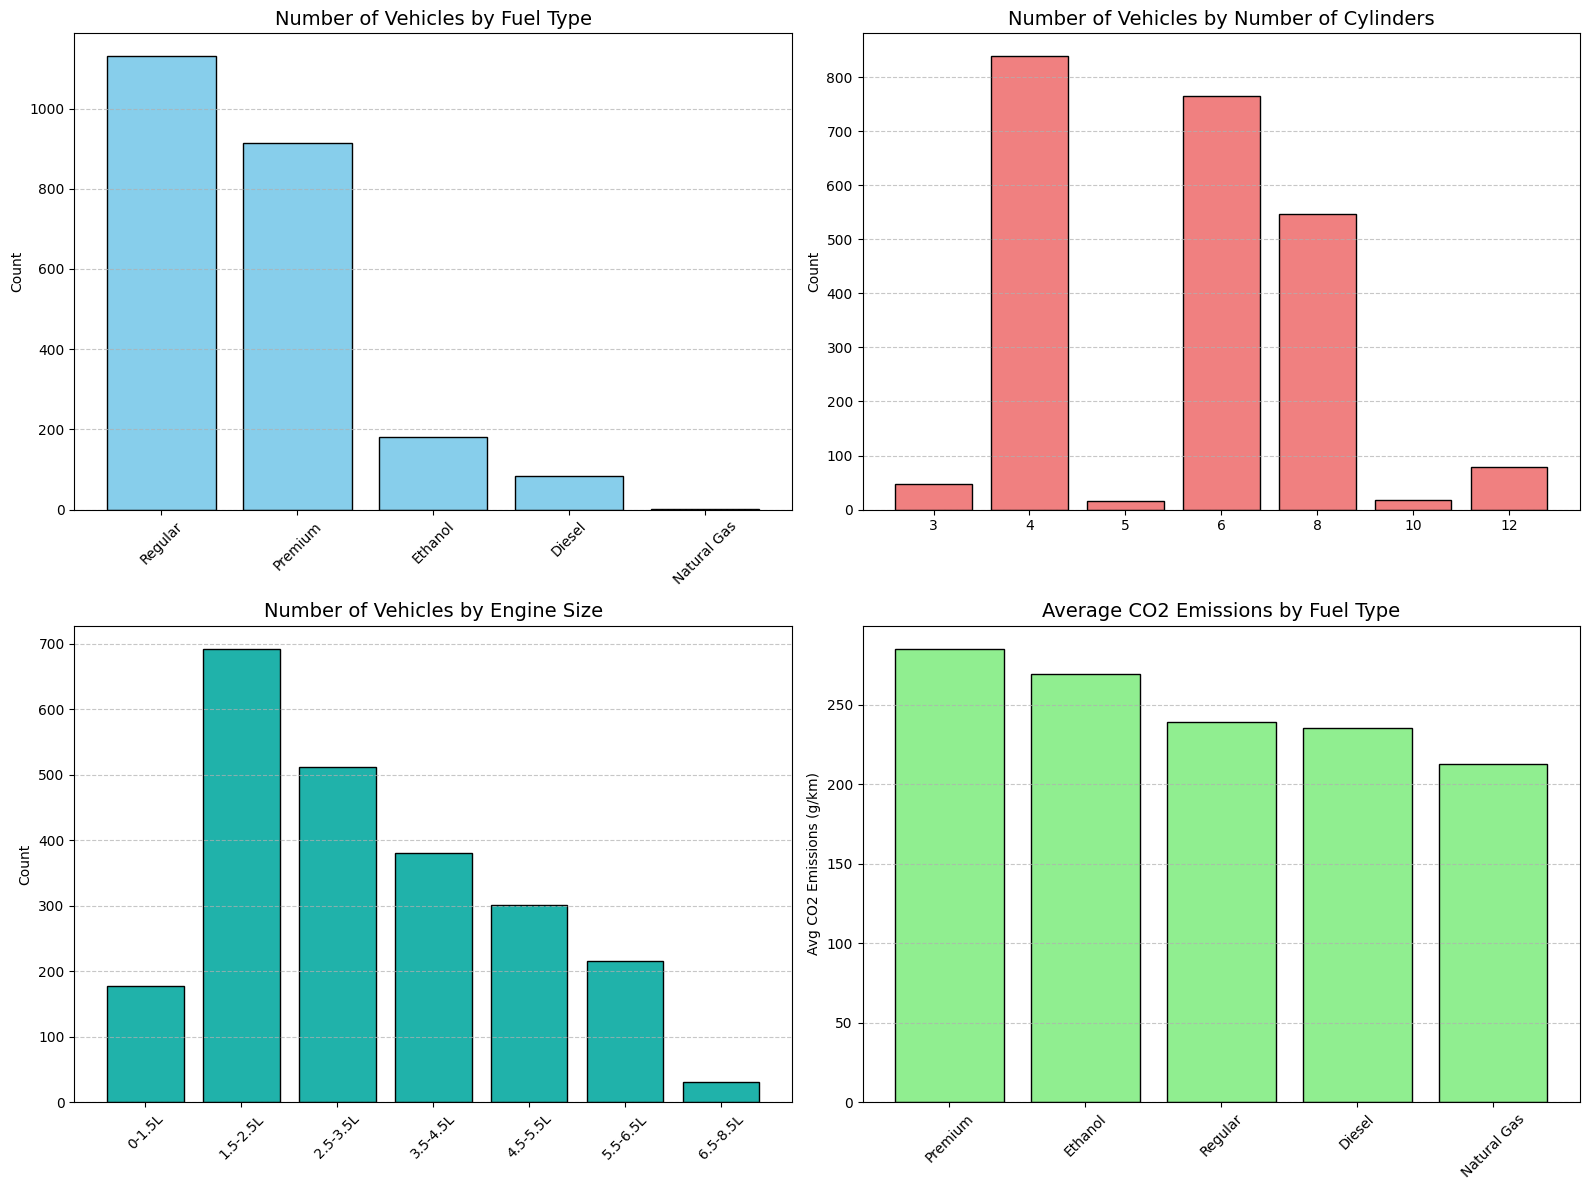

In [106]:


# Load the dataset
df = pd.read_csv('CO2_Cleaned_No_Outliers.csv')

# --- Data Preparation ---
# 1. Fuel Type Mapping
fuel_map = {'Z': 'Premium', 'X': 'Regular', 'D': 'Diesel', 'E': 'Ethanol', 'N': 'Natural Gas'}
df['Fuel Name'] = df['Fuel Type'].map(fuel_map)
fuel_counts = df['Fuel Name'].value_counts()
fuel_avg = df.groupby('Fuel Name')['CO2 Emissions(g/km)'].mean().sort_values(ascending=False)

# 2. Cylinder Counts
cylinder_counts = df['Cylinders'].value_counts().sort_index()

# 3. Engine Size Bins
engine_bins = [0, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 8.5]
engine_labels = ['0-1.5L', '1.5-2.5L', '2.5-3.5L', '3.5-4.5L', '4.5-5.5L', '5.5-6.5L', '6.5-8.5L']
df['Engine Size Bin'] = pd.cut(df['Engine Size(L)'], bins=engine_bins, labels=engine_labels)
engine_counts = df['Engine Size Bin'].value_counts().sort_index()

# --- Plotting in a Single Plane (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Vehicles by Fuel Type (Top Left)
axes[0, 0].bar(fuel_counts.index, fuel_counts.values, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Number of Vehicles by Fuel Type', fontsize=14)
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Vehicles by Cylinders (Top Right)
axes[0, 1].bar(cylinder_counts.index.astype(str), cylinder_counts.values, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Number of Vehicles by Number of Cylinders', fontsize=14)
axes[0, 1].set_ylabel('Count')

# Plot 3: Vehicles by Engine Size (Bottom Left)
axes[1, 0].bar(engine_counts.index.astype(str), engine_counts.values, color='lightseagreen', edgecolor='black')
axes[1, 0].set_title('Number of Vehicles by Engine Size', fontsize=14)
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Avg CO2 by Fuel Type (Bottom Right)
axes[1, 1].bar(fuel_avg.index, fuel_avg.values, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Average CO2 Emissions by Fuel Type', fontsize=14)
axes[1, 1].set_ylabel('Avg CO2 Emissions (g/km)')
axes[1, 1].tick_params(axis='x', rotation=45)

# Add grids and adjust layout
for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Contributed by: Sindhu M, Zaid Ali
Model Performance:
- R² Score: 0.7045
- Mean Absolute Error: 29.01 g/km
- Root Mean Squared Error: 36.27 g/km
- Mean Squared Error: 1315.20 (g/km)²


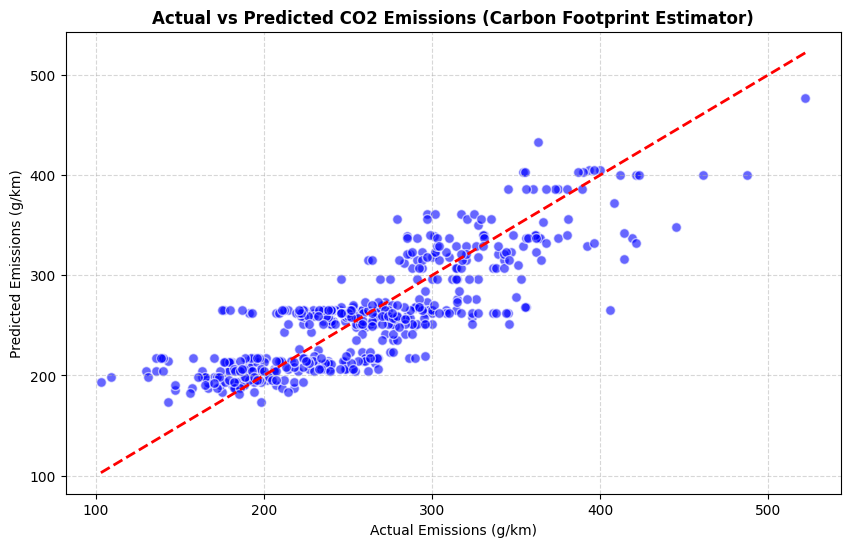

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error,root_mean_squared_error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Linear Regression Model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# 5. Make Predictions and Evaluate
y_pred = regressor.predict(X_test)
r2_score_value = r2_score(y_test, y_pred)
mae_value = mean_absolute_error(y_test, y_pred)
mse_value = mean_squared_error(y_test, y_pred)
rmse_value = root_mean_squared_error(y_test, y_pred)

print("Contributed by: Sindhu M, Zaid Ali")
print(f"Model Performance:")
print(f"- R² Score: {r2_score_value:.4f}")
print(f"- Mean Absolute Error: {mae_value:.2f} g/km")
print(f"- Root Mean Squared Error: {rmse_value:.2f} g/km")
print(f"- Mean Squared Error: {mse_value:.2f} (g/km)²")
# 6. Visualization: Actual vs Predicted using Matplotlib (plt)
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6, color='blue', edgecolors='w', s=50)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

# Adding labels and title
plt.title('Actual vs Predicted CO2 Emissions (Carbon Footprint Estimator)', fontweight='bold')
plt.xlabel('Actual Emissions (g/km)')
plt.ylabel('Predicted Emissions (g/km)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Model Performance:
- R² Score: 0.7045
- Mean Absolute Error: 29.01 g/km
- Root Mean Squared Error: 36.27 g/km
- Mean Squared Error: 1315.20 (g/km)²


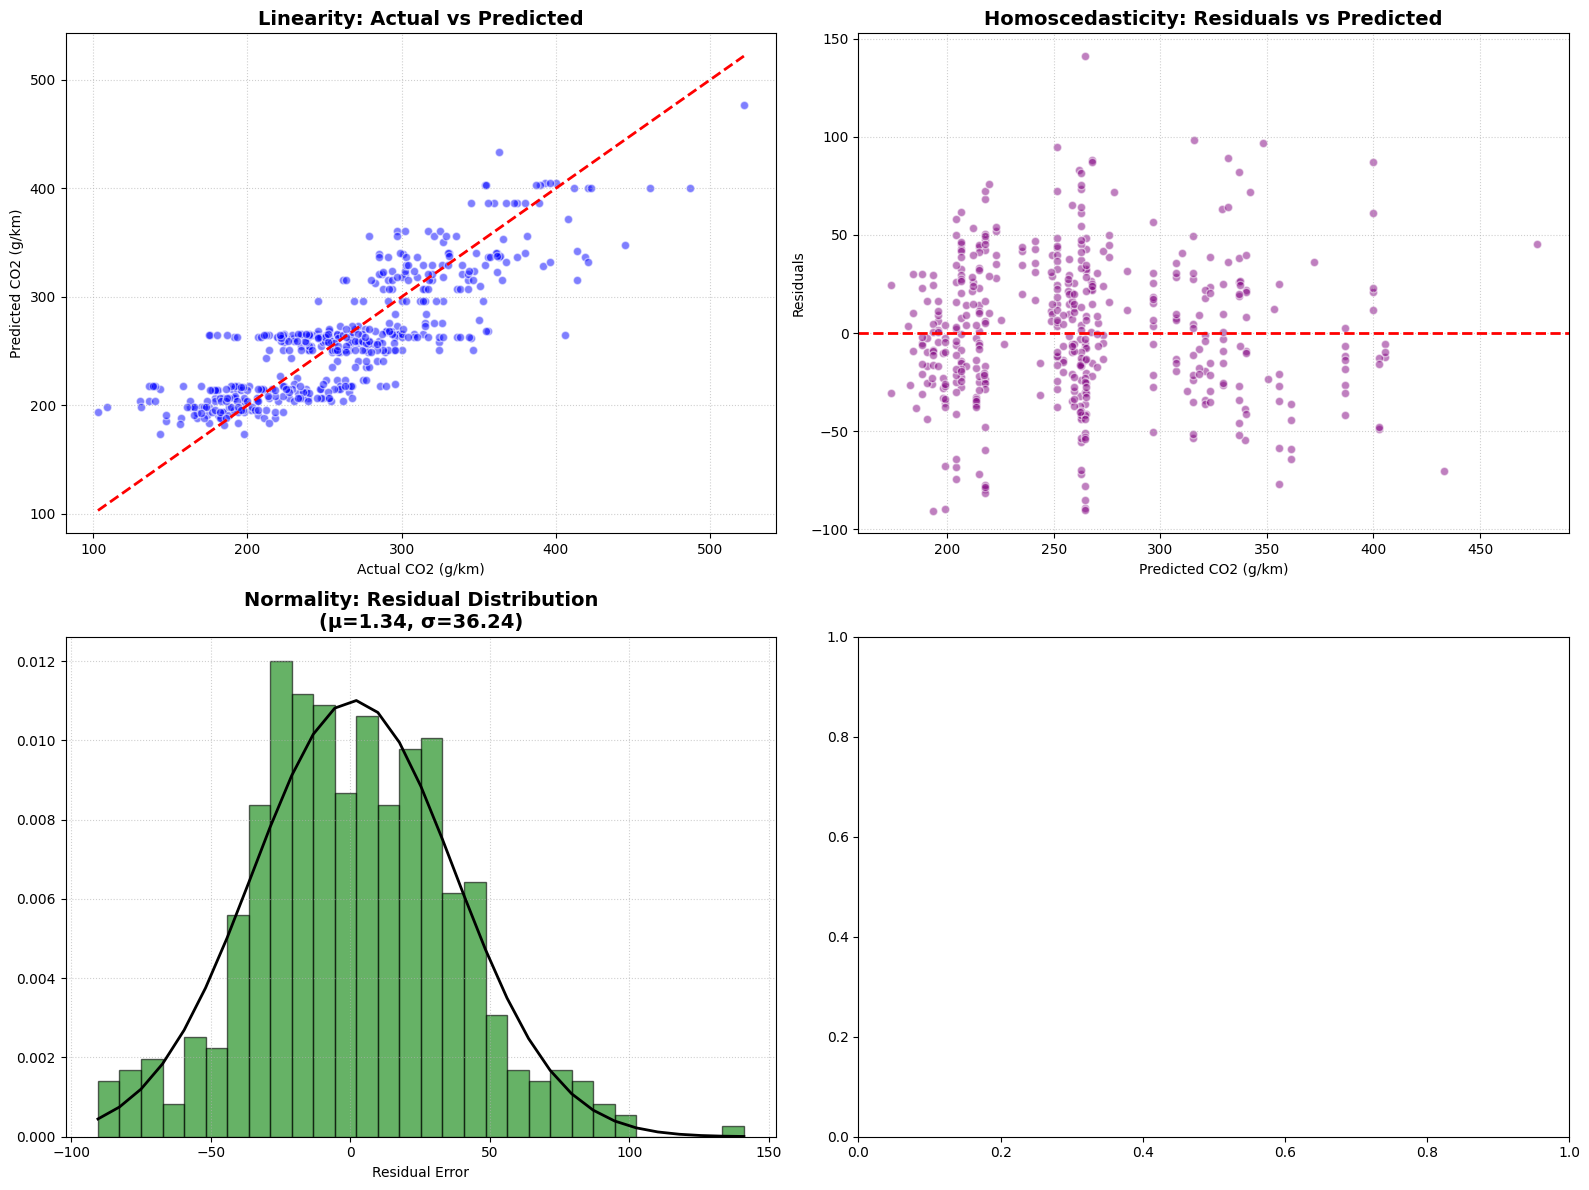

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error,root_mean_squared_error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the Linear Regression Model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# 5. Make Predictions and Evaluate
y_pred = regressor.predict(X_test)
residuals = y_test - y_pred
r2_score_value = r2_score(y_test, y_pred)
mae_value = mean_absolute_error(y_test, y_pred)
mse_value = mean_squared_error(y_test, y_pred)
rmse_value = root_mean_squared_error(y_test, y_pred)


print(f"Model Performance:")
print(f"- R² Score: {r2_score_value:.4f}")
print(f"- Mean Absolute Error: {mae_value:.2f} g/km")
print(f"- Root Mean Squared Error: {rmse_value:.2f} g/km")
print(f"- Mean Squared Error: {mse_value:.2f} (g/km)²")
# 6. Visualization: Actual vs Predicted using Matplotlib (plt)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Graph 1: Linearity (Actual vs Predicted) ---
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, color='blue', edgecolors='white')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
axes[0, 0].set_title('Linearity: Actual vs Predicted', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Actual CO2 (g/km)')
axes[0, 0].set_ylabel('Predicted CO2 (g/km)')
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# --- Graph 2: Homoscedasticity (Residual Plot) ---
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, color='purple', edgecolors='white')
axes[0, 1].axhline(y=0, color='red', lw=2, linestyle='--')
axes[0, 1].set_title('Homoscedasticity: Residuals vs Predicted', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Predicted CO2 (g/km)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# --- Graph 3: Normality (Histogram of Residuals) ---
n, bins, patches = axes[1, 0].hist(residuals, bins=30, density=True, color='green', alpha=0.6, edgecolor='black')
mu, std = norm.fit(residuals)
axes[1, 0].plot(bins, norm.pdf(bins, mu, std), 'k', linewidth=2)
axes[1, 0].set_title(f'Normality: Residual Distribution\n(μ={mu:.2f}, σ={std:.2f})', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Residual Error')
axes[1, 0].grid(True, linestyle=':', alpha=0.6)


plt.tight_layout()
plt.show()

In [109]:
import seaborn as sns
df1 = pd.read_csv("CO2 Emissions.csv")

In [110]:
df1.columns = ['Engine_Size','Cylinders','Fuel_Type','CO2_Emissions']

Here after Contributed by: Sonali


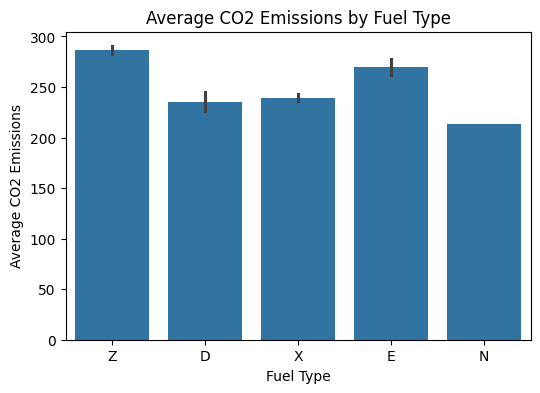

In [111]:
print("Here after Contributed by: Sonali")
plt.figure(figsize=(6,4))

sns.barplot(x='Fuel_Type', y='CO2_Emissions', data=df1)

plt.title("Average CO2 Emissions by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average CO2 Emissions")

plt.show()

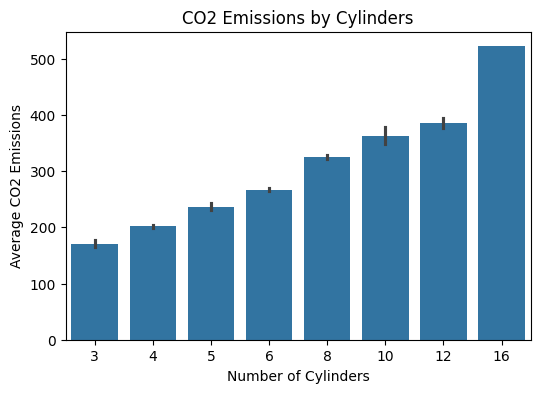

In [112]:
plt.figure(figsize=(6,4))

sns.barplot(x='Cylinders', y='CO2_Emissions', data=df1)

plt.title("CO2 Emissions by Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("Average CO2 Emissions")

plt.show()

In [113]:
df1['Engine_Group'] = pd.cut(df1['Engine_Size'],bins=4)

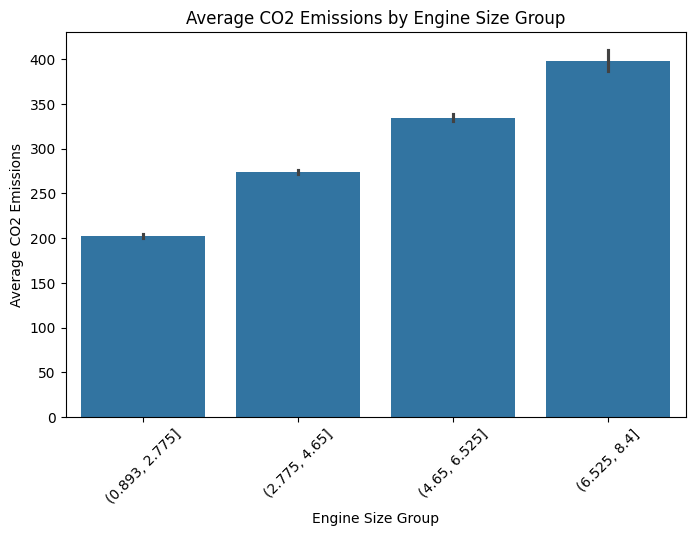

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(x='Engine_Group', y='CO2_Emissions', data=df1)

plt.title("Average CO2 Emissions by Engine Size Group")
plt.xlabel("Engine Size Group")
plt.ylabel("Average CO2 Emissions")
plt.xticks(rotation=45)

plt.show()

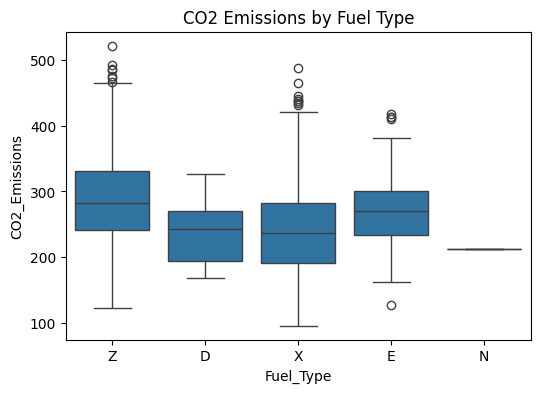

In [115]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Fuel_Type', y='CO2_Emissions', data=df1)

plt.title("CO2 Emissions by Fuel Type")
plt.show()

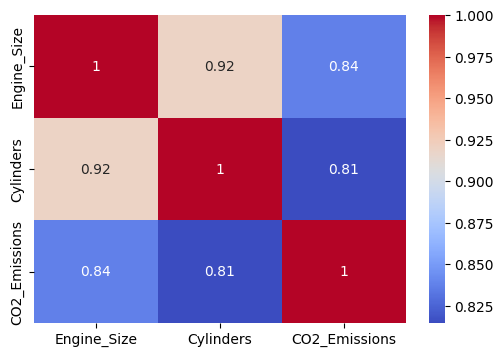

In [116]:
plt.figure(figsize=(6,4))
sns.heatmap(df1.select_dtypes(include=['float64','int64']).corr(method='pearson'), annot=True,cmap='coolwarm')
plt.show()

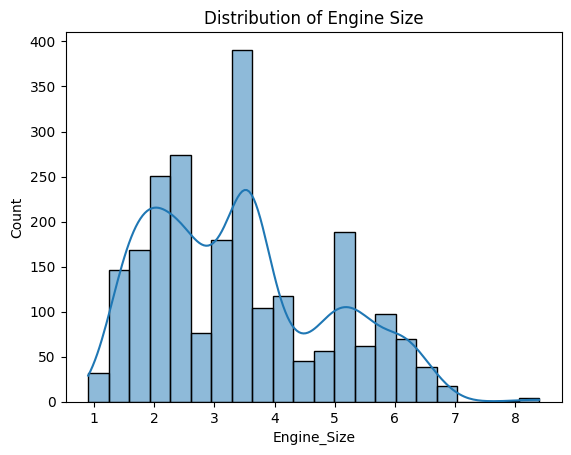

In [117]:
sns.histplot(df1['Engine_Size'], kde=True)
plt.title("Distribution of Engine Size")
plt.show()

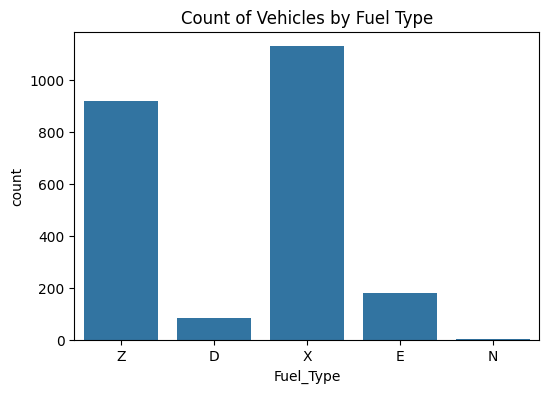

In [118]:
plt.figure(figsize=(6,4))
sns.countplot(x='Fuel_Type', data=df1)

plt.title("Count of Vehicles by Fuel Type")
plt.show()